In [ ]:
### IMPORTS

!pip install scikit_posthocs
!pip install ipython-autotime
!pip install seaborn==0.13.2

%load_ext autotime

import string
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import scipy.stats as ss
import scikit_posthocs as scihoc
import seaborn as sns

from matplotlib import patches
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from os import listdir
from re import search, escape, sub
from scipy import integrate

import gspread
from google.colab import auth, drive
from google.auth import default
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)
drive.mount('/content/gdrive/', force_remount=True)

In [ ]:
from typing import Union, List, Tuple

from matplotlib import colors
from matplotlib.axes import SubplotBase
from matplotlib.colorbar import ColorbarBase, Colorbar
from matplotlib.colors import ListedColormap

def sign_plot(
        x: Union[List, np.ndarray, pd.DataFrame],
        g: Union[List, np.ndarray] = None,
        flat: bool = False,
        labels: bool = True,
        cmap: List = None,
        cbar_ax_bbox: List = None,
        ax: SubplotBase = None,
        ticksize = 12,
        **kwargs) -> Union[SubplotBase, Tuple[SubplotBase, Colorbar]]:
    """Significance plot, a heatmap of p values (based on Seaborn).
    Parameters
    ----------
    x : Union[List, np.ndarray, DataFrame]
        If flat is False (default), x must be an array, any object exposing
        the array interface, containing p values. If flat is True, x must be
        a sign_array (returned by :py:meth:`scikit_posthocs.sign_array`
        function).
    g : Union[List, np.ndarray]
        An array, any object exposing the array interface, containing
        group names.
    flat : bool
        If `flat` is True, plots a significance array as a heatmap using
        seaborn. If `flat` is False (default), plots an array of p values.
        Non-flat mode is useful if you need to  differentiate significance
        levels visually. It is the preferred mode.
    labels : bool
        Plot axes labels (default) or not.
    cmap : list
        1) If flat is False (default):
        List consisting of five elements, that will be exported to
        ListedColormap method of matplotlib. First is for diagonal
        elements, second is for non-significant elements, third is for
        p < 0.001, fourth is for p < 0.01, fifth is for p < 0.05.
        2) If flat is True:
        List consisting of three elements, that will be exported to
        ListedColormap method of matplotlib. First is for diagonal
        elements, second is for non-significant elements, third is for
        significant ones.
        3) If not defined, default colormaps will be used.
    cbar_ax_bbox : list
        Colorbar axes position rect [left, bottom, width, height] where
        all quantities are in fractions of figure width and height.
        Refer to `matplotlib.figure.Figure.add_axes` for more information.
        Default is [0.95, 0.35, 0.04, 0.3].
    ax : SubplotBase
        Axes in which to draw the plot, otherwise use the currently-active
        Axes.
    kwargs
        Keyword arguments to be passed to seaborn heatmap method. These
        keyword args cannot be used: cbar, vmin, vmax, center.
    Returns
    -------
    ax : matplotlib.axes._subplots.AxesSubplot
        Axes object with the heatmap.
    cbar : matplotlib.colorbar.Colorbar
        ColorBar object if `flat` is set to False.
    Examples
    --------
    >>> x = np.array([[ 1, 1, 1],
                      [ 1, 1, 0],
                      [ 1, 0, 1]])
    >>> ph.sign_plot(x, flat = True)
    """
    for key in ['cbar', 'vmin', 'vmax', 'center']:
        if key in kwargs:
            del kwargs[key]

    if isinstance(x, pd.DataFrame):
        df = x.copy()
    else:
        x = np.array(x)
        g = g or np.arange(x.shape[0])
        df = pd.DataFrame(np.copy(x), index=g, columns=g)

    dtype = df.values.dtype

    if not np.issubdtype(dtype, np.integer) and flat:
        raise ValueError("X should be a sign_array or DataFrame of integers")
    elif not np.issubdtype(dtype, np.floating) and not flat:
        raise ValueError("X should be an array or DataFrame of float p values")

    if not cmap and flat:
        # format: diagonal, non-significant, significant
        cmap = ['1', '#fbd7d4', '#1a9641']
    elif not cmap and not flat:
        # format: diagonal, non-significant, p<0.001, p<0.01, p<0.05
        cmap = ['1', '#fbd7d4', '#005a32', '#238b45', '#a1d99b']

    if flat:
        np.fill_diagonal(df.values, -1)
        hax = sns.heatmap(df, vmin=-1, vmax=1, cmap=ListedColormap(cmap),
                      cbar=False, ax=ax, **kwargs)
        if not labels:
            hax.set_xlabel('')
            hax.set_ylabel('')
        return hax

    else:
        df[(x < 0.001) & (x >= 0)] = 1
        df[(x < 0.01) & (x >= 0.001)] = 2
        df[(x < 0.05) & (x >= 0.01)] = 3
        df[(x >= 0.05)] = 0

        np.fill_diagonal(df.values, -1)

        if len(cmap) != 5:
            raise ValueError("Cmap list must contain 5 items")

        hax = sns.heatmap(
            df, vmin=-1, vmax=3, cmap=ListedColormap(cmap), center=1,
            cbar=False, ax=ax, **kwargs)
        if not labels:
            hax.set_xlabel('')
            hax.set_ylabel('')
        hax.tick_params(axis = 'both', labelsize = ticksize)

        cbar_ax = hax.figure.add_axes(cbar_ax_bbox or [0.95, 0.35, 0.04, 0.3])
        cbar = ColorbarBase(cbar_ax, cmap=(ListedColormap(cmap[2:] + [cmap[1]])), norm=colors.NoNorm(),
                            boundaries=[0, 1, 2, 3, 4])
        cbar.set_ticks(list(np.linspace(0, 3, 4)))
        cbar.set_ticklabels(['p < 0.001', 'p < 0.01', 'p < 0.05', 'NS'])
        cbar.outline.set_linewidth(1)
        cbar.outline.set_edgecolor('0.5')
        cbar.ax.tick_params(size=0)

        return hax, cbar

time: 2.27 ms (started: 2025-02-07 08:08:45 +00:00)


In [ ]:
### PATH

experiment_to_analyse = '' # INSERT HERE NAME OF EXPERIMENT
path = f"" # INSERT HERE PATH TO DATA

In [ ]:
### UTILITY FUNCTIONS

def stat_rounder(p):
  if p < 0.0001:
    return 'p < 0.0001'
  else:
    return f'p={str(round(p, 4))}'

def errorfill(x, y, yerr, color=None, alpha_fill=0.3, ax=None, label=None, lw = 2):
    ax = ax if ax is not None else plt.gca()
    if color is None:
        color = ax._get_lines.color_cycle.next()
    if np.isscalar(yerr) or len(yerr) == len(y):
        ymin = y - yerr
        ymax = y + yerr
    elif len(yerr) == 2:
        ymin, ymax = yerr
    ax.plot(x, y, color=color, label=label, linewidth = lw)
    ax.fill_between(x, ymax, ymin, color=color, alpha=alpha_fill)

### COLOR SCHEMES

colordict = {'Brassica': '#8d8089',
             'Pelt': '#50414c',
             'Brinjal': '#5e3a42',
             'Middleton Pink': '#fde7e5',
             'Calluna': '#ccc8ce',
             'Sugaroom Red': '#d0bfcd',
             'Preference Red': '#6d4247',
             'Sulking Room Pink': "#a0837f",
             'Cinder Rose': "#c6a4a6",
             'Nancys Blushes': "#ecb7b8",
             'Rangwali': "#bf7a8f",
             'Lake Red': "#c8526a",
             'Rectory Red': "#a53c49",
             'Incarnadine': "#a04344",
             'Blazer': "#b64f48",
             'Harissa': "#ae5043",
             'Charlottes Locks': "#d65f3d",
             'Book Room': "#ab6758",
             'Red Earth': "#c57b67",
             'India Yellow': "#cb9e59",
             'Sudbury Yellow': "#dcb771",
             'Babouche': "#ecc363",
             'Yellowcake': "#ebe05e",
             'Yellow Ground': "#f2cf86",
             'Dayroom Yellow': "#f7e29d",
             'Dorset Cream': "#efd5a1",
             'Tallow': "#fdedd7",
             'Farrows Cream': "#efdbb3",
             'Hay': "#dec795",
             'Citrona': "#dbcc7c",
             'Churlish Green': "#c8bd83",
             'Yeabridge Green': "#909e6e",
             'Bancha': "#686a47",
             'Duck Green': "#465741",
             'Green Ground': "#dbdab6",
             'Cooking Apple Green': "#c4c6a5",
             'Lichen': "#a1a189",
             'Breakfast Room Green': "#94a68a",
             'Calke Green': "#758769",
             'Emerald Green': "#7bae72",
             'Verdigris': "#3e8b67",
             'Vardo': "#427e83",
             'Arsenic': "#84b59c",
             'Green Smoke': "#737c70",
             'Oval Room Blue': "#8b9d9b",
             'Green Blue': "#acbdb2",
             'Dix Blue': "#99b0ab",
             'Parma Gray': "#b1bfc5",
             'Blue Ground': "#a1c5c8",
             'Stone Blue': "#7997a1",
             'Inchyra Blue': "#586768",
             'Hague Blue': "#3d4e57",
             'Stiffkey Blue': "#4d5b6a",
             'St Giles Blue': "#599ec4",
             'Ultra Marine Blue': "#5d82a1",
             'Cooks Blue': "#6a90b4",
             'Lulworth Blue': "#a0b8c8",
             'Pitch Blue': "#636e8f",
             'Imperial Purple': "#55566b",
             'Scotch Blue': "#41404c",
             'Paean Black': "#494248",
             'Railings': "#45494b",
             'Off Black': "#444546",
             'Pitch Black': "#3b3938",
             'Pigeon': "#a0a093",
             'Old White': "#cec3ad",
             'Strong White': "#e5e0db",
             'Cabbage White': "#e8eeea"}

colors_deepspec = ['Brassica',
                   'Pelt',
                   'Brinjal',
                   'Incarnadine',
                   'Harissa',
                   'India Yellow',
                   'Bancha',
                   'Duck Green',
                   'Hague Blue',
                   'Stiffkey Blue']

colors_spec = ['Rangwali',
               'Lake Red',
               'Rectory Red',
               'Charlottes Locks',
               'Babouche',
               'Emerald Green',
               'Verdigris',
               'Vardo',
               'Ultra Marine Blue',
               'St Giles Blue']

colors_lightspec = ['Nancys Blushes',
                    'Cinder Rose',
                    'Book Room',
                    'Dayroom Yellow',
                    'Yeabridge Green',
                    'Breakfast Room Green',
                    'Dix Blue',
                    'Blue Ground',
                    'Lulworth Blue']

time: 2.53 ms (started: 2025-02-07 08:08:46 +00:00)


In [ ]:
label_map = '' ### INSERT HERE GOOGLESHEET WITH WELL-LABEL MAPPING

worksheet = gc.open(label_map).sheet1
order = worksheet.get_all_values()
order = pd.DataFrame(order)
order = order.drop(0)
order.columns = ['Well', 'Label']
order['Label'] = order['Label'].str.replace('_', ' ')
order

In [ ]:
### FUNCTION FOR DATA DETECTION IN TEKAN FILES

def detect_table(data: pd.DataFrame,
                 initial_start: int = 0):
    start = None
    data_r = pd.DataFrame()
    for index, val in data.iloc[initial_start:, 0].items():
        # print(f'{index}, {val}')
        if val == '<>':
            start = index + 1
            index_name = '<>'
            data_type = 'single'

            data_to_check = data.iloc[start:start + 8, 1:13].replace(r'nan|None', np.nan, regex=True)
            data_to_check = data_to_check.select_dtypes(include=[np.number])
            index_col = data.iloc[start:start + 8, 0]

            if data_to_check.notna().values.any():
              data_r = pd.concat([index_col, data_to_check], axis=1)
              break
        elif val == 'Cycle Nr.':
            start = index + 1
            for index_, val_ in  enumerate(data.iloc[start:, 0]):
                if val_ == 'End Time':
                    end = index_ - 1
                    data_to_check = data.iloc[start:start + end, 1:]
                    data_to_check.drop('Temp. [°C]', inplace=True, axis=1)
                    data_to_check.dropna(axis=1, how='all', inplace=True)
                    index_col = data.iloc[start:end, 0]
                    # print(index_col)
                    index_name = '<>'
                    data_type = 'kinetics'
                    if data_to_check.notna().values.any():
                      data_r = pd.concat([index_col, data_to_check], axis=1)
                      break
        elif val == 'Wavel.':
            start = index + 1
            for index_, val_ in  enumerate(data.iloc[start:, 0]):
                # print(data.iloc[start:, 0])
                if val_ == 'End Time':
                    end = index_ - 1
                    data_to_check = data.iloc[start:start + end, 1:]
                    data_to_check.dropna(axis=1, how='all', inplace=True)
                    index_col = data.iloc[start:start + end, 0]
                    data_to_check.columns = data.iloc[start-1, 1:]
                    index_name = '<>'
                    data_type = 'spectra'
                    if data_to_check.notna().values.any():
                      data_r = pd.concat([index_col, data_to_check], axis=1)
                      data_r.set_index(data_r.columns[0], inplace = True)
                      break

    if not data_r.empty and data_type == 'single':
      data_r.columns = data.iloc[index].values.tolist()
      data_r.set_index(index_name, inplace=True)
      data_r.columns.name = None
      well_names = []
      for row_name in data_r.index.values.tolist():

        for col_name in data_r.columns.values.tolist():
          well_names.append(row_name+str(int(col_name)))
      data_flat = pd.DataFrame({'values': data_r.values.ravel(), 'Well': well_names})

      return data_flat, start, data_type, data_r
    elif not data_r.empty and data_type != 'single':
      return None, start, data_type, data_r
    else:
      return 'error', 'error', 'error', 'error'

def sheet_od(sheet_name):
  plate_number = int(sheet_name.replace('Plate ', ''))
  if plate_number < 6:
    return 0.1
  else:
    return 0.01

### DATA OPENING AND PROCESSING

filelist = [x for x in listdir(path) if x.endswith('.xlsx')]

full_data = pd.DataFrame()
for file_num, filename in enumerate(filelist[:]):
  file = pd.ExcelFile(f'{path}{filename}')
  file_df_533 = pd.DataFrame()

  print(f'file: {filename}')
  for sheet_num, sheet_name in enumerate(file.sheet_names[:]):
    print(f'{sheet_num}: {sheet_name}')
    if 'mKate' in sheet_name:

      sheet = pd.read_excel(file, sheet_name = sheet_name)


      file_df_533_sheet = order.copy()

      raw_data_533, next_start_533, data_type, data_r_533 = detect_table(data=sheet)
      data_r_533 = data_r_533.transpose()
      data_r_533['Sum'] = data_r_533.apply(lambda row: row[2:].sum(), axis = 1)
      file_df_533_sheet = file_df_533_sheet.merge(right = data_r_533,
                                                  how = 'inner',
                                                  left_on = ['Well'],
                                                  right_index = True)
      file_df_533_sheet = file_df_533_sheet[file_df_533_sheet.Label != 'empty']
      file_df_533_sheet_n = pd.DataFrame()
      for index, row in file_df_533_sheet.iterrows():
        norm_value = row[533]
        if norm_value == 'ignored' or norm_value == 'Ignored':
          continue
        else:
          modified_row = np.divide(row[2:-1].values.tolist(), norm_value)

          modified_row = pd.DataFrame(pd.concat([row[:2], pd.Series(modified_row), row[-1:]])).transpose()
          file_df_533_sheet_n = pd.concat([file_df_533_sheet_n, modified_row], axis = 0)
      file_df_533_sheet_n.columns = file_df_533_sheet.columns

      file_df_533_sheet_n['Sheet_name'] = sheet_name



      full_data = pd.concat([full_data, file_df_533_sheet_n], axis = 0)

full_data.reset_index(inplace = True)
full_data = full_data[full_data.columns[1:]]
full_data[full_data.columns[2:-2]] = full_data[full_data.columns[2:-2]].astype(float)
full_data.to_csv(f'{path}{experiment_to_analyse}_full_data_sum_normalized.csv', index = False)
full_data

,Label,488,503,518,533,548,563,578,593,608,623,638,653,Sum
0,non-cp-mKate2,0.050636,0.090923,0.13067,0.135642,0.113984,0.094182,0.079045,0.061997,0.060174,0.063921,0.06334,0.055484,247946
0,non-cp-mKate2,0.061941,0.096359,0.120301,0.114262,0.091549,0.072167,0.061763,0.056365,0.067588,0.084922,0.090337,0.082446,56134
0,non-cp-mKate2,0.056575,0.104793,0.152178,0.159297,0.138105,0.116199,0.095769,0.063266,0.048932,0.027954,0.021287,0.015644,41997
0,non-cp-mKate2,0.059806,0.107076,0.15586,0.158307,0.136775,0.113842,0.093441,0.064957,0.046593,0.027874,0.021322,0.014147,295471
0,non-cp-mKate2,0.035088,0.017544,0.157895,0.017544,0.087719,0.035088,0.035088,0.035088,0.0,0.192982,0.298246,0.087719,57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,pNK497,0.051292,0.099439,0.15184,0.162452,0.140142,0.118973,0.09758,0.066711,0.047429,0.028334,0.021553,0.014254,6330634
0,empty,0.05,0.05,0.1,0.2,0.05,0.0,0.0,0.1,0.0,0.0,0.45,0.0,20
0,empty,0.2,0.0,0.1,0.05,0.0,0.15,0.25,0.0,0.25,0.0,0.0,0.0,20
0,empty,0.25,0.208333,0.166667,0.041667,0.0,0.0,0.083333,0.041667,0.208333,0.0,0.0,0.0,24


time: 4.33 s (started: 2025-01-21 18:57:40 +00:00)


<ipython-input-20-deb039670bd1>:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_to_plot['N_of_label'] = data_to_plot.apply(lambda row: r'$\bf{' + label_and_number[row['Label']] + '}$', axis=1)
<ipython-input-20-deb039670bd1>:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_to_plot['label_and_number'] = data_to_plot.apply(lambda row:  f"{row['N_of_label']} {row['Label']}", axis=1)
<ipython-input-20-deb039670bd1>:150: UserWarning: set_ticklabels() should only be used with a fixed number of ticks,

Results of Kruskal, p=4.425759986394343e-06, H=45.22704081632651


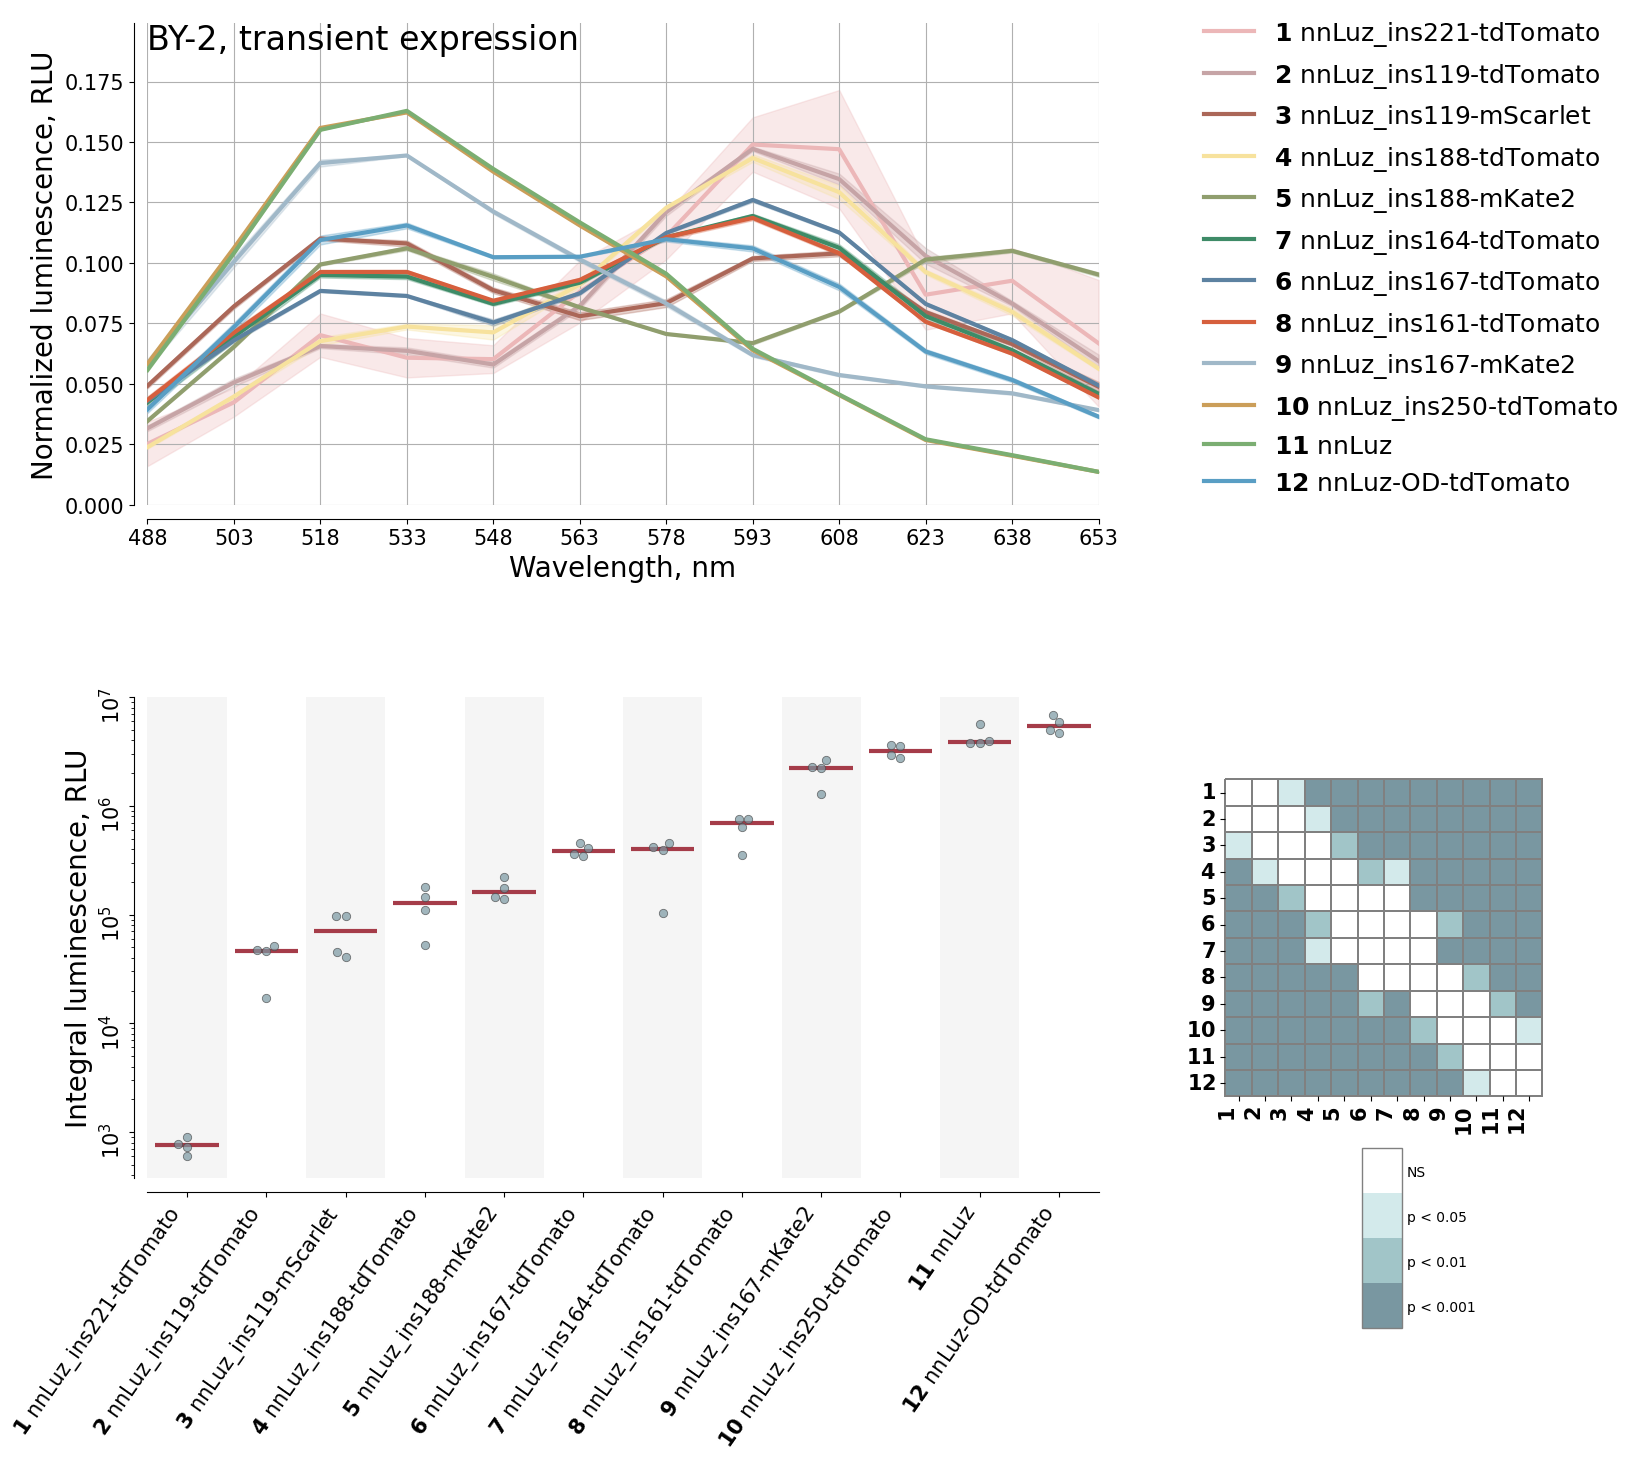

time: 10.8 s (started: 2025-02-07 08:17:52 +00:00)


In [ ]:
full_data = pd.read_csv(f'{path}{experiment_to_analyse}_full_data_sum_normalized.csv')
wl = full_data.columns[1:-1].values.tolist()

select_list = ['nnLuz',
               'nnLuz-OD-tdTomato',
               'nnLuz_ins116-tdTomato',
               'nnLuz_ins119-tdTomato',
               'nnLuz_ins161-tdTomato',
               'nnLuz_ins164-tdTomato',
               'nnLuz_ins167-tdTomato',
               'nnLuz_ins188-tdTomato',
               'nnLuz_ins221-tdTomato',
               'nnLuz_ins250-tdTomato',
               'nnLuz_ins188-mKate2',
               'nnLuz_ins119-mKate2',
               'nnLuz_ins167-mKate2',
               'nnLuz_ins119-mScarlet',
               'nnLuz_ins167-mScarlet'
               ]


medianprops = {'color': colordict['Rectory Red'],
               'linewidth': 4}
capprops = {
            'color': 'black',
            'linewidth': 0.0
            }
whiskerprops = {
            'color': 'black',
            'linewidth': 0.0}
boxprops = {
            'edgecolor': 'black',
            'linewidth': 0.0,
            'alpha': 0}

xlabel_size = 20
ylabel_size = 20
yticklabel_size = 15
xticklabel_size = 15
title_size = 24
suptitle_size = 20
legend_size = 18
signplot_size = 15
instick_size = 9

hue = None
palette = None
color = colordict['Stone Blue']
size = 6
alpha = 0.7
linewidth = 0.6
medianprops = {'color': colordict['Rectory Red'],
                'linewidth': 3}

labels_quantity = len(full_data.Label.unique())

colorlist = ['Nancys Blushes',
             'Cinder Rose',
             'Book Room',
             'Dayroom Yellow',
             'Yeabridge Green',
             'Verdigris',
             'Ultra Marine Blue',
             'Charlottes Locks',
             'Lulworth Blue',
             'India Yellow',
             'Emerald Green',
             'St Giles Blue',]

data_to_plot = full_data[(full_data.Label.isin(select_list)) & (full_data.Sum > 100)]
val_col = 'Sum'
label_col = 'Label'
label_and_number = {x: str(y+1) for y, x in
                    enumerate(data_to_plot.groupby('Label').median(numeric_only=True).sort_values(val_col, ascending=True).index.values)}
data_to_plot['N_of_label'] = data_to_plot.apply(lambda row: r'$\bf{' + label_and_number[row['Label']] + '}$', axis=1)
data_to_plot['label_and_number'] = data_to_plot.apply(lambda row:  f"{row['N_of_label']} {row['Label']}", axis=1)


fig = plt.figure(figsize=(18, 15))
gs = fig.add_gridspec(ncols=2, nrows=2, width_ratios=[3.0, 1], height_ratios=[1, 1], wspace = 0.20, hspace = 0.4)
ax = fig.add_subplot(gs[0, 0])

data_slice_grouped = data_to_plot[['label_and_number', 'Sum'] + wl].groupby('label_and_number').describe()
data_slice_grouped = data_slice_grouped.sort_values(('Sum', 'mean'), ascending = True)


for index_num, index in enumerate(data_slice_grouped.index.values.tolist()):
  mean = data_slice_grouped.xs('mean', axis = 1, level = 1).loc[index]
  std = data_slice_grouped.xs('std', axis = 1, level = 1).loc[index]
  label = index
  errorfill(wl, mean[1:], std[1:], color = colordict[colorlist[index_num]], ax = ax, label = label, lw = 3)


sns.despine(offset = 10, trim = False, ax=ax)

ax.set_xticks(wl)
ax.set_ylabel(f'Normalized luminescence, RLU', fontsize = ylabel_size)
ax.set_xlabel('Wavelength, nm', fontsize = xlabel_size)
ax.tick_params(axis = 'both', labelsize = xticklabel_size)
ax.legend(loc = (1.1, -0.), frameon = False, fontsize = legend_size, ncol=1)
ax.set_ylim(0, 0.199)
ax.set_xlim(wl[0], wl[-1])

ax.grid(0.4)

label_col = 'label_and_number'
ax2 = fig.add_subplot(gs[1, 0])

sorting_order = data_to_plot.groupby(label_col).median(numeric_only = True).sort_values(val_col, ascending = True).index.values.tolist()
sns.boxplot(data=data_to_plot,
            x=label_col,
            y=val_col,
            color = 'white',
            medianprops = medianprops,
            capprops = capprops,
            whiskerprops = whiskerprops,
            boxprops = boxprops,
            order = sorting_order,
            showfliers = False,
            ax = ax2)

sns.swarmplot(data=data_to_plot,
              x=label_col,
              y=val_col,
              color = color,
              order = sorting_order,
              hue = hue,
              palette = palette,
              ax = ax2,
              alpha = alpha,
              dodge = True,
              edgecolor=colordict['Off Black'],
              size = size,
              linewidth=linewidth
              )

ax2.set_xlabel(None, fontsize = xlabel_size)
ax2.set_ylabel('Integral luminescence, RLU', fontsize = ylabel_size)
ax2.set_yscale('log')
sns.despine(offset = 10, trim = False, ax=ax2)
ax2.tick_params(axis = 'both', labelsize = xticklabel_size, rotation = 90)
ax2.set_xticklabels(ax2.get_xticklabels(),  rotation = 55, ha = 'right')

ylim_low = 1000
ylim_high = 10000000
ax2.set_ylim(ymax = ylim_high)

xTickPos = ax2.get_xticks()
xTickPos = xTickPos[:] #slice off the last as it is the top of the plot
# create bars at yTickPos that are the length of our greatest xtick and have a height equal to our tick spacing
ax2.bar(xTickPos, ylim_high, width=(xTickPos[1]-xTickPos[0]), color=['whitesmoke','w'])
ax2.set_xlim(-0.5, len(sorting_order) - 0.5)


ax3 = fig.add_subplot(gs[1, 1])
c_label_col = 'N_of_label'
############ <><><><><><><><>< STATS
q1 = data_to_plot.copy()
q1['datapoint']=q1[val_col].apply(float)

data_ = [q1.loc[ids, 'datapoint'].values for ids in q1.groupby(c_label_col).groups.values()]
H, p = ss.kruskal(*data_)
print(f"Results of Kruskal, p={p}, H={H}")
res = scihoc.posthoc_conover(q1, val_col='datapoint', group_col=c_label_col, p_adjust = 'holm-sidak')
sorting_order2 = [x.split(' ')[0] for x in sorting_order]


res=res.reindex(sorting_order2).transpose().reindex(sorting_order2)
heatmap_args = {'linewidths': 0.25, 'linecolor': '0.5', 'clip_on': False, 'square': True, 'cbar_ax_bbox': [0.80, 0.01, 0.022, 0.12]}
cmap = ['1', '1', colordict['Stone Blue'], colordict['Blue Ground'],"#d3eaeb"]

ax3 = sign_plot(res, **heatmap_args, ax = ax3, ticksize = signplot_size, cmap = cmap)

ax3[0].set_xticklabels(ax3[0].get_xticklabels(),  rotation = 90, ha = 'right')
ax3[0].set_yticklabels(ax3[0].get_yticklabels(),  rotation = 0, ha = 'right')

ax.set_title(f"BY-2, transient expression", fontsize = title_size, y = 0.93, loc = 'left')

ver = 'ver2.2'

plt.savefig(f'{path}{experiment_to_analyse}_all_normed_{ver}.png',
            dpi = 400,
            bbox_inches='tight',
            transparent=False,
            facecolor='white')
plt.savefig(f'{path}{experiment_to_analyse}_all_normed_{ver}.pdf',
            # dpi = 400,
            bbox_inches='tight',
            transparent=False,
            facecolor='white')